In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Understanding Data

In [173]:
df = pd.read_csv("bank_transactions.csv")
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [174]:
# Check the shape of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 1048567 rows and 9 columns.


In [175]:
# Column names
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='object')

In [176]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [177]:
# Statistical summary of the dataset
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [178]:
# Check for missing values
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


## Insights
* The dataset has 1048567 rows and 9 columns.
* CustomerDOB and TransactionDate are stored as string (must be datetime())
* CustomerDOB, CustGender, CustLocation and CustAccountBalance have missing values

# Data Preprocessing

In [179]:
# Convert 'CustomerDOB' and 'TransactionDate' to datetime format
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1048567 non-null  object        
 1   CustomerID               1048567 non-null  object        
 2   CustomerDOB              1045170 non-null  datetime64[ns]
 3   CustGender               1047467 non-null  object        
 4   CustLocation             1048416 non-null  object        
 5   CustAccountBalance       1046198 non-null  float64       
 6   TransactionDate          1048567 non-null  datetime64[ns]
 7   TransactionTime          1048567 non-null  int64         
 8   TransactionAmount (INR)  1048567 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 72.0+ MB


In [181]:
# Created a new column Age and Check the range of birth years
df['Age'] = (pd.Timestamp.today() - df['CustomerDOB']).dt.days/365

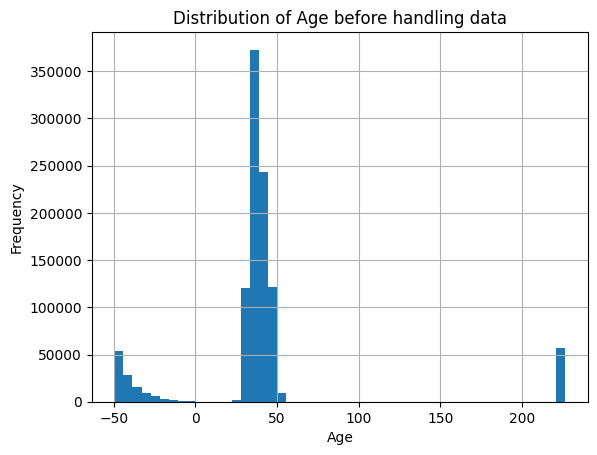

In [184]:
df['Age'].hist(bins=50)
plt.title("Distribution of Age before handling data")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [185]:
print("Minimum age before handling:", df['Age'].min())
print("Maximum age before handling:", df['Age'].max())

Minimum age before handling: -49.608219178082194
Maximum age before handling: 226.57260273972602


In [186]:
# If age < 18 or age > 100 it will be considered invalid age
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 100)]

print("Invalid ages:", len(invalid_age))
print("Percentage:", len(invalid_age)/len(df)*100)

Invalid ages: 175059
Percentage: 16.69507051051578


In [187]:
# Converting invalid age into null values
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

In [188]:
# Filling null values with median(robust to outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)

In [189]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0
Age,0


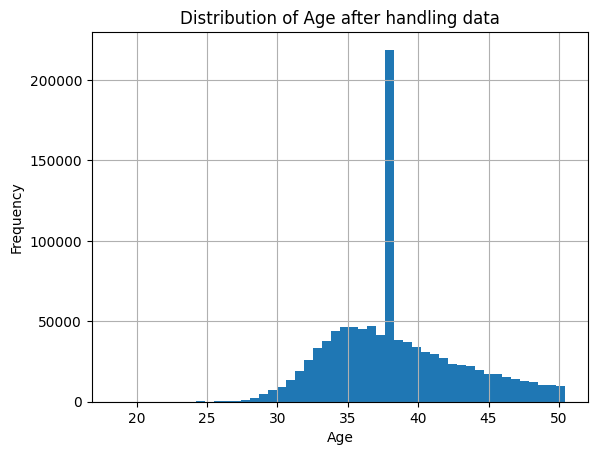

<Figure size 640x480 with 0 Axes>

In [192]:
df['Age'].hist(bins=50)
plt.title("Distribution of Age after handling data")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.savefig("age_distribution.png")

In [193]:
print("Minimum age before handling:", df['Age'].min())
print("Maximum age before handling:", df['Age'].max())

Minimum age before handling: 18.427397260273974
Maximum age before handling: 50.45753424657534


In [194]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0
Age,0


In [195]:
# Filled gender with mode because gender is categorical variable
df['CustGender'].fillna(df['CustGender'].mode()[0], inplace=True)
# Filled customer location with unknown because it is categorical variable
df['CustLocation'].fillna("Unknown", inplace=True)
# Filling customer account balance with median(robust to outliers)
df['CustAccountBalance'].fillna(df['CustAccountBalance'].median(), inplace=True)

In [196]:
# Dropping CustomerDOB because age feature have been extracted and hence it is redundant
df.drop(columns=['CustomerDOB'], inplace=True)

In [197]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustGender,0
CustLocation,0
CustAccountBalance,0
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0
Age,0


In [198]:
df.dtypes

,0
TransactionID,object
CustomerID,object
CustGender,object
CustLocation,object
CustAccountBalance,float64
TransactionDate,datetime64[ns]
TransactionTime,int64
TransactionAmount (INR),float64
Age,float64


# Feature Engineering

In [199]:
# Divided age into age groups instead of analyzing individually
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60, 100], labels=['18-25', '26-35', '36-45', '46-60', '60+'])

In [200]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
36-45,698368
26-35,238914
46-60,110804
18-25,481
60+,0


In [201]:
# Monthly Transactions
df['Month'] = df['TransactionDate'].dt.month_name()

In [202]:
df['Month'].value_counts()

,count
Month,
August,430314
September,158882
October,51069
July,48422
November,47287
April,47246
March,47046
June,46225
February,43787


In [203]:
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()

In [204]:
df['DayOfWeek'].value_counts()

,count
DayOfWeek,
Tuesday,170318
Saturday,161430
Wednesday,157297
Friday,156250
Sunday,139365
Monday,135282
Thursday,128625


In [205]:
# Created Transaction Hour column
# Converts TransactionTime into string
df['TransactionTime'] = df['TransactionTime'].astype(str)
# Pads the left side with zeros until it is 6 characters long.
df['TransactionTime'] = df['TransactionTime'].str.zfill(6)
# Extracts the first 2 characters of the 6-character string and converts them to an integer
df['Hour'] = df['TransactionTime'].str[:2].astype(int)

In [206]:
# Divided customer type based on customer account balance
def customer_type(balance):
    if balance >= 200000:
        return 'High Value'
    elif balance >= 50000:
        return 'Medium Value'
    else:
        return 'Low Value'

df['CustomerType'] = df['CustAccountBalance'].apply(customer_type)

In [207]:
df['CustomerType'].value_counts()

,count
CustomerType,
Low Value,761973
Medium Value,182682
High Value,103912


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1048567 non-null  object        
 1   CustomerID               1048567 non-null  object        
 2   CustGender               1048567 non-null  object        
 3   CustLocation             1048567 non-null  object        
 4   CustAccountBalance       1048567 non-null  float64       
 5   TransactionDate          1048567 non-null  datetime64[ns]
 6   TransactionTime          1048567 non-null  object        
 7   TransactionAmount (INR)  1048567 non-null  float64       
 8   Age                      1048567 non-null  float64       
 9   AgeGroup                 1048567 non-null  category      
 10  Month                    1048567 non-null  object        
 11  DayOfWeek                1048567 non-null  object        
 12  

In [209]:
total_customers = df['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 884265


In [210]:
total_transactions = df['TransactionID'].nunique()
print("Total Transactions:", total_transactions)

Total Transactions: 1048567


In [211]:
total_amount = df['TransactionAmount (INR)'].sum()
print("Total Transaction Amount:", round(total_amount,2))

Total Transaction Amount: 1650795731.57


In [212]:
avg_transaction = df['TransactionAmount (INR)'].mean()
print("Average Transaction Amount:", round(avg_transaction,2))

Average Transaction Amount: 1574.34


In [213]:
avg_balance = df['CustAccountBalance'].mean()
print("Average Account Balance:", round(avg_balance,2))

Average Account Balance: 115180.75


In [214]:
maximum_balance = df['CustAccountBalance'].max()
print("Maximum Account Balance:", round(maximum_balance,2))

Maximum Account Balance: 115035495.1


In [215]:
multiple_transaction_customer = (df['CustomerID'].value_counts().gt(1).sum())
print("Customers with multiple transactions:", multiple_transaction_customer)

Customers with multiple transactions: 143612


# Exploratory Data Analysis

**What is the age distribution of customers?**

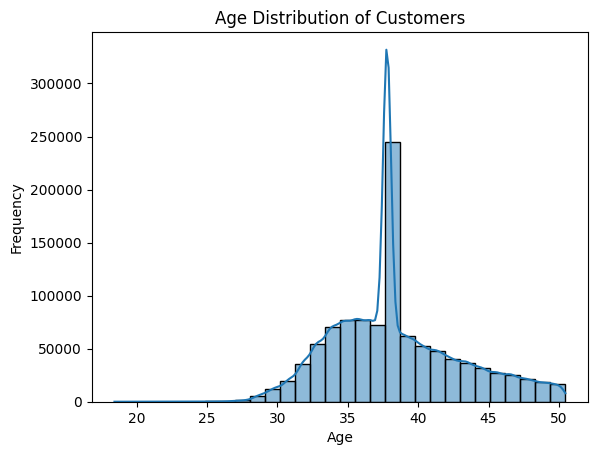

<Figure size 640x480 with 0 Axes>

In [217]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
plt.savefig("age_distribution.png")

**What is the gender distribution of customers?**

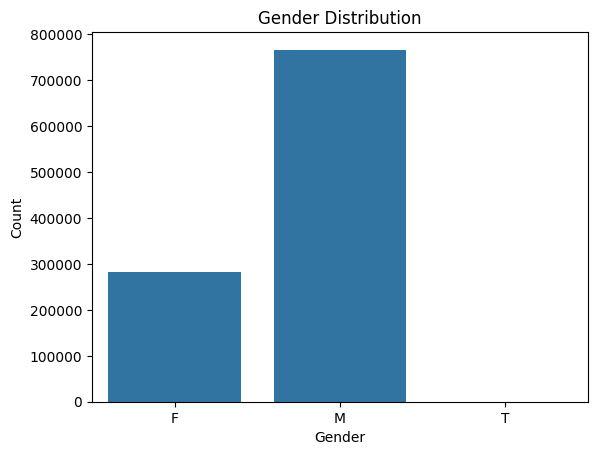

<Figure size 640x480 with 0 Axes>

In [219]:
sns.countplot(data=df, x='CustGender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
plt.savefig("gender_distribution.png")

**Which locations have the highest number of customers?**

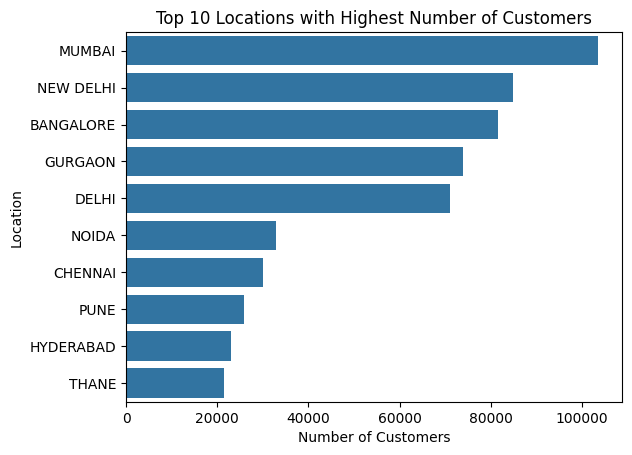

<Figure size 640x480 with 0 Axes>

In [221]:
top_locations = df['CustLocation'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title('Top 10 Locations with Highest Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Location')
plt.show()
plt.savefig("top_10_location.png")

**What is the distribution of account balances?**

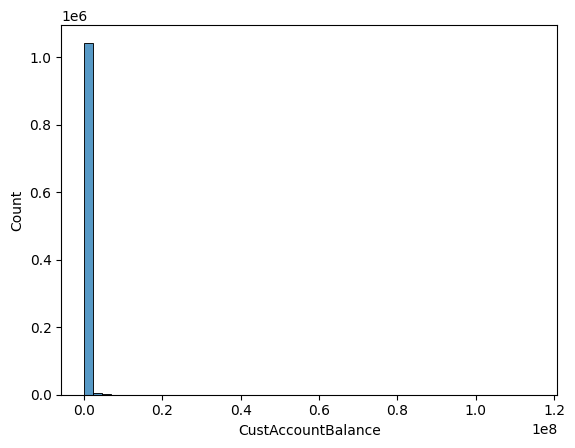

In [223]:
sns.histplot(df['CustAccountBalance'], bins=50)
plt.savefig("account_balance.png")

### Insight
* Most customers maintain relatively low account balances.
* Few customers hold exceptionally high account balances.

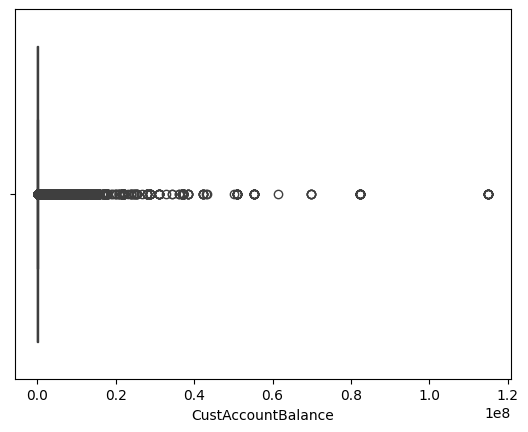

In [224]:
sns.boxplot(x=df['CustAccountBalance'])
plt.savefig("account_balance2.png")

### Insight
* Account balance distribution is heavily right-skewed.
* Numerous extreme outliers indicate premium customers.

**Which age group contributes the highest transaction amount?**

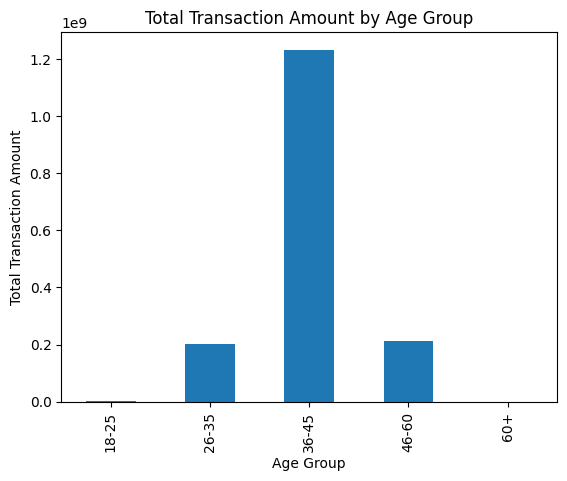

<Figure size 640x480 with 0 Axes>

In [225]:
age_spend = df.groupby('AgeGroup')['TransactionAmount (INR)'].sum()
age_spend.plot(kind='bar')
plt.title('Total Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Transaction Amount')
plt.show()
plt.savefig("age_group.png")

**At what hours do customers transact the most?**

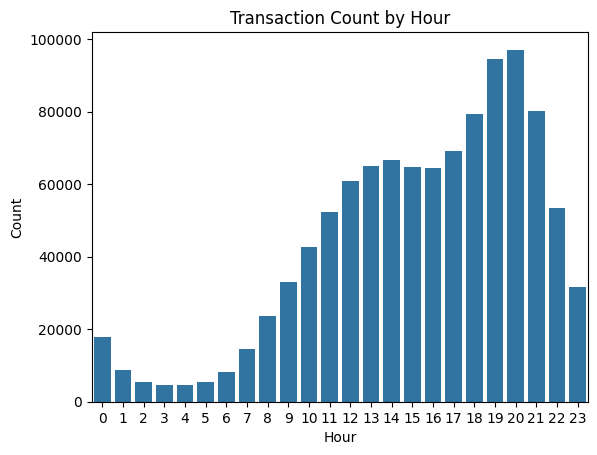

<Figure size 640x480 with 0 Axes>

In [227]:
sns.countplot(data=df, x='Hour')
plt.title('Transaction Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()
plt.savefig("transaction_hour.png")

**Which day of the week has the highest transaction activity?**

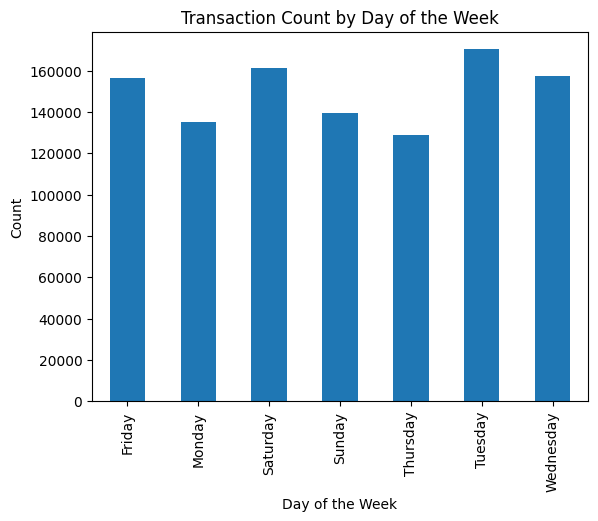

<Figure size 640x480 with 0 Axes>

In [229]:
weekday_transaction = df.groupby('DayOfWeek')['TransactionID'].count()
weekday_transaction.plot(kind='bar')
plt.title('Transaction Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.show()
plt.savefig("weekday_transaction.png")

**Which month has the highest transaction volume and value?**

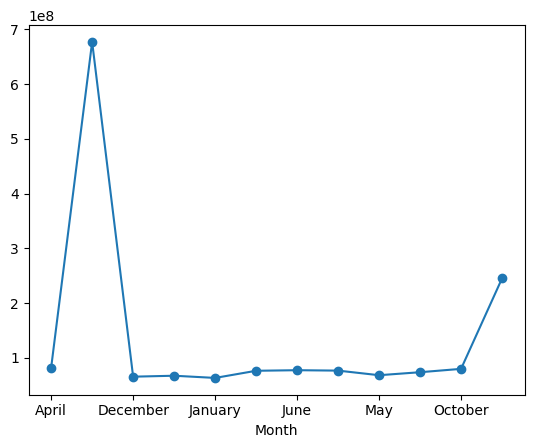

In [231]:
monthly_amount = df.groupby('Month')['TransactionAmount (INR)'].sum()
monthly_amount.plot(kind='line', marker='o')
plt.savefig("monthly_amount.png")

**Who are the top 10 customers by transaction amount?**

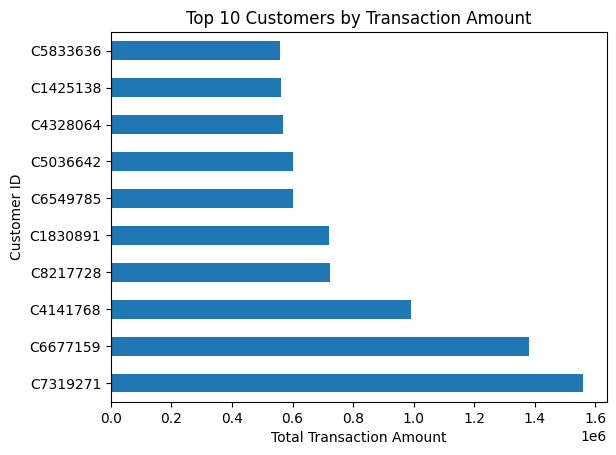

In [233]:
top_customers = (df.groupby('CustomerID')['TransactionAmount (INR)'].sum().sort_values(ascending=False).head(10))
top_customers.plot(kind='barh')
plt.title('Top 10 Customers by Transaction Amount')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Customer ID')
plt.savefig("top_10_customers.png")

**Is there a relationship between account balance and transaction amount?**

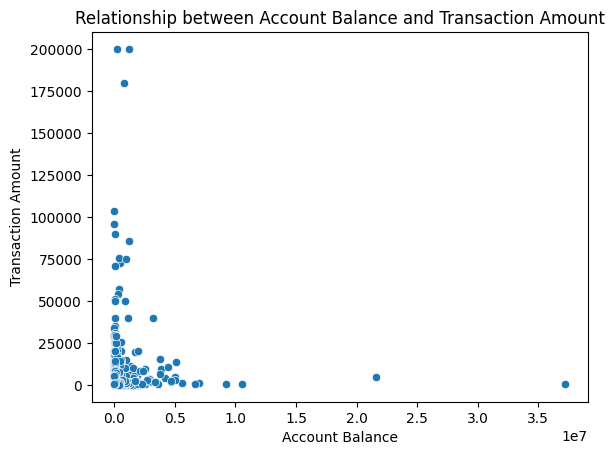

<Figure size 640x480 with 0 Axes>

In [235]:
sns.scatterplot(data=df.sample(5000),x='CustAccountBalance', y='TransactionAmount (INR)')
plt.title('Relationship between Account Balance and Transaction Amount')
plt.xlabel('Account Balance')
plt.ylabel('Transaction Amount')
plt.show()
plt.savefig("account_balance_transaction.png")

**How are customers distributed across Customer Types**

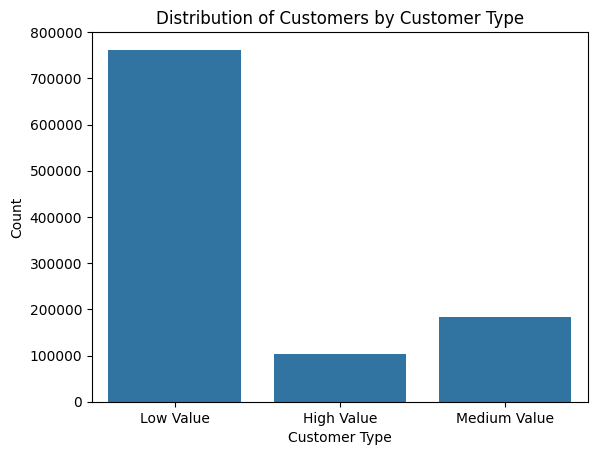

<Figure size 640x480 with 0 Axes>

In [241]:
sns.countplot(data=df, x='CustomerType')
plt.title('Distribution of Customers by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()
plt.savefig("customer_type.png")

In [242]:
numerical_columns = df.select_dtypes(include=['number'])
categorical_columns = df.select_dtypes(include=['object', 'category'])

print(f"The dataframe has {len(numerical_columns.columns)} numerical columns: {list(numerical_columns.columns)}")
print(f"The dataframe has {len(categorical_columns.columns)} categorical columns: {list(categorical_columns.columns)}")

The dataframe has 4 numerical columns: ['CustAccountBalance', 'TransactionAmount (INR)', 'Age', 'Hour']
The dataframe has 9 categorical columns: ['TransactionID', 'CustomerID', 'CustGender', 'CustLocation', 'TransactionTime', 'AgeGroup', 'Month', 'DayOfWeek', 'CustomerType']


**Is there any relationship between customer age, account balance, transaction amount, and transaction hour?**

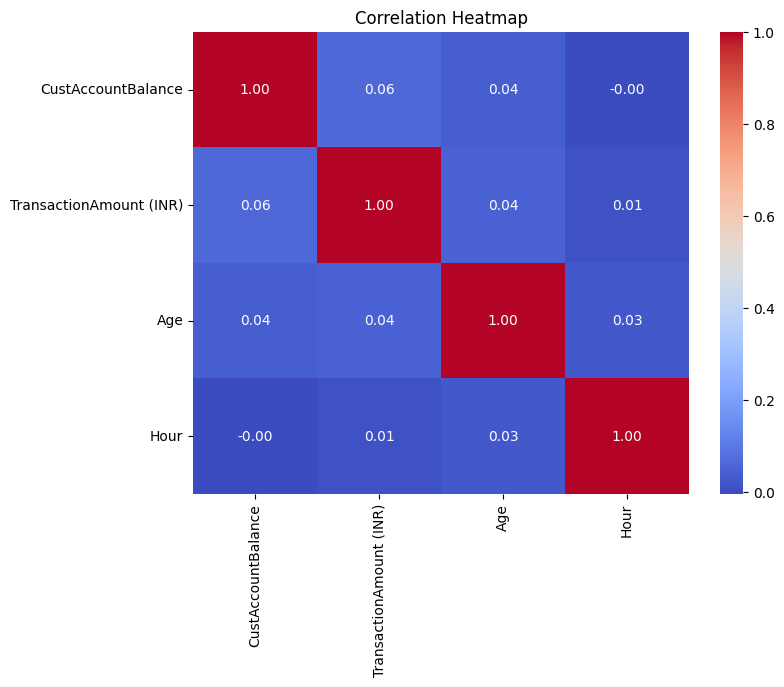

<Figure size 640x480 with 0 Axes>

In [243]:
numeric_columns = ["CustAccountBalance", "TransactionAmount (INR)", "Age", "Hour"]
plt.figure(figsize=(8,6))
correlation = df[numeric_columns].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
plt.savefig("correlation_heatmap.png")

* Customer account balance has a very weak positive relationship with transaction amount (0.06).
* Customer age has almost no relationship with account balance or transaction amount.
* Transaction hour does not significantly influence transaction amount.
* Overall, the variables are largely independent of each other.